Nombre y apellidos: Alfonso Íñiguez Cortés \
Correo: aic35@alu.ua.es \
Grupo: 3 

# DFS. Exploración de grafos

In [4]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown 

Implementación del algoritmo DFS:

In [5]:
def dfs_numpy(graph, source, target):
    nodes = list(graph.nodes())
    adjacency_matrix = nx.to_numpy_array(graph, nodelist=nodes)

    visited = np.zeros(len(nodes), dtype=bool)
    source_index = nodes.index(source)
    target_index = nodes.index(target)
    visited[source_index] = True

    to_explore = [source_index]
    current_position = len(to_explore) - 1 

    parent = np.ones(len(nodes), dtype=int) * -1
    steps = 0

    while len(to_explore) > 0:
        steps += 1
        current_index = to_explore[current_position]
        to_explore.pop(current_position)

        if current_index == target_index:
            break

        neighbors = np.where(adjacency_matrix[current_index] == 1)[0]
        for neighbor_index in neighbors:
            if not visited[neighbor_index]:
                visited[neighbor_index] = True
                to_explore.append(neighbor_index)
                current_position = len(to_explore) - 1
                parent[neighbor_index] = current_index

        if len(to_explore) > 0:
            current_position = len(to_explore) - 1

    path = []
    if parent[target_index] != -1 or source_index == target_index:
        current = target_index
        while current != -1:
            path.insert(0, nodes[current])
            current = parent[current]

    return steps, path

## Ejercicios

### Ejercicio 1

El algoritmo DFS es un algoritmo de exploración de grafos. Este algoritmo explora el grafo
en profundidad: elige un vecino y sigue explorando por esa rama todo lo que puede antes de
volver atrás. A diferencia de BFS, DFS **no garantiza el camino más corto** entre dos nodos,
sino que encuentra un camino válido explorando tan lejos como sea posible antes de retroceder.

### Explicación algoritmo

- #### Bloque 1 - Inicialización
---

In [ ]:
nodes = list(graph.nodes())
adjacency_matrix = nx.to_numpy_array(graph, nodelist=nodes)

visited = np.zeros(len(nodes), dtype=bool)
source_index = nodes.index(source)
target_index = nodes.index(target)
visited[source_index] = True

to_explore = [source_index]
current_position = len(to_explore) - 1 

parent = np.ones(len(nodes), dtype=int) * -1
steps = 0

- **nodes** &rarr; Lista ordenada de todos los nodos del grafo. La lista es necesaria puesto que se trabaja con los índices de los nodos, no con los nombres reales de estos.

- **adjacency_matrix** &rarr; Matriz NxN donde la celda ```[i][j] = 1``` si hay una arsita entre el nodo i y el nodo j. Si no hay arista, el valor correspondiente es 0.

- **visited** &rarr; Array de valores booleanos, uno por nodo. Este array nos dice que nodo ya ha sido explorado, lo cual sirve para no explorar el mismo nodo más de una vez (podría casar bucles)

- **source_index** &rarr; Índice del nodo donde comienza la búsqueda

- **target_index** &rarr; Índice del nodo que queremos alcanzar 

- **visited[source_index]** &rarr; Marcamos como visitado el nodo desde el cual comenzamos la búsqueda

- **to_explore** &rarr; Cola pendiente del BFS, es decir, los nodos pendientes de explorar. Esta lista comienza en el nodo de origen

- **current_position** &rarr; Puntero que apunta siempre al **último** elemento de la lista.
A diferencia de BFS, aquí siempre procesamos el elemento más reciente, imitando el
comportamiento **LIFO (Last In First Out)** de una pila.

- **parent** &rarr; Array que guarda, por cada nodo, desde qué nodo hemos llegado hasta a él. Este array es el que se usa para reconstruir el camino final. El array esta inicializado a -1 (todos) ya que ningún nodo tiene padre todavía

- **steps** &rarr; Contador de iteraciones del bucle principal

- #### Bucle principal
---

In [ ]:
while len(to_explore) > 0:
    steps += 1
    current_index = to_explore[current_position]
    to_explore.pop(current_position)

    if current_index == target_index:
        break

    neighbors = np.where(adjacency_matrix[current_index] == 1)[0]
    for neighbor_index in neighbors:
        if not visited[neighbor_index]:
            visited[neighbor_index] = True
            to_explore.append(neighbor_index)
            current_position = len(to_explore) - 1
            parent[neighbor_index] = current_index

    if len(to_explore) > 0:
        current_position = len(to_explore) - 1

- _while_ &rarr; El bucle continúa mientras haya nodos en la pila. A diferencia de BFS, aquí se hace **pop()** del último elemento, imitando el comportamiento LIFO de una pila. Esto garantiza que el algoritmo explore en profundidad antes de retroceder.

- **current_index** &rarr;  Seleccionamos y eliminamos el nodo en la cima de la pila

- **steps** &rarr; Sumamos uno por iteración

- _if_ &rarr; Si el nodo actual es igual que el nodo destino, hemos encontrado el camino más corto y el bucle finaliza. Cuando DFS encuentra un camino, este no tiene porqué ser el óptimo

- **neighbors** &rarr; Mira la fila del nodo actual en la matriz de adyacencia y devuelve los índices donde haya un uno, es decir, donde exista una arsita, es decir, sus vecinos

- _for_ &rarr; Bucle donde se recorren los vecinos del nodo actual. Para cada vecino no visitado: lo marcamos como visitado, lo añadimos a la pila
y actualizamos **current_position** para que apunte al nuevo último elemento


- #### Bloque 3 - Reconstrucción del camino
---

In [ ]:
path = []
if parent[target_index] != -1 or source_index == target_index:
    current = target_index
    while current != -1:
        path.insert(0, nodes[current])
        current = parent[current]

return steps, path

- **path** &rarr; Lista donde se van a guardar los índices del camino más corto entre el _source_ y el _target_

- _if_ &rarr; Si el nodo final no tiene padres o el nodo inicial y el final son el mismo nodo no se puede realizar la reconstrucción

- **current** &rarr; Comenzamos la reconstrucción desde atrás, luego asignamos el nodo destino al nodo actual

- _while_ &rarr; El único nodo sin padre (valor -> -1) es el nodo origen. Este bucle recorre los nodos hasta llegar al padre (justo antes de procesarlo)

- **path.insert** &rarr; Insertamos el nodo actual al principio de la lista. Lo hacemos así puesto que recorremos el camino hacia atrás (obtendríamos el camino pero al revés)

- **current = parent[current]** &rarr; Seleccionamos el padre del nodo actual para seguir reconstruyendo el camino

#### DFS con prints

In [8]:
def dfs_numpy(graph, source, target):
    """"
    Función que implementa el algoritmo DFS. Se usan prints para que se muestre
    que pasos esta siguiendo el algoritmo.

    Args
    -------
        - graph: Grafo que se va a explorar
        - source: Nodo del que se comienza la exploración
        - target: Nodo que se quiere encontrar

    Returns
    --------
        - steps: Número de pasos que usa BFS para encontrar el camino
        - path: Camino entre source y target
    
    """

    display(Markdown(f'## Analizando el grafo con DFS \n---'))
    nodes = list(graph.nodes())
    adjacency_matrix = nx.to_numpy_array(graph, nodelist=nodes)

    visited = np.zeros(len(nodes), dtype=bool)
    source_index = nodes.index(source)
    target_index = nodes.index(target)
    visited[source_index] = True

    to_explore = [source_index]
    current_position = len(to_explore) - 1 

    parent = np.ones(len(nodes), dtype=int) * -1
    steps = 0

    # Inicialización
    display(Markdown(f'### <u>Datos iniciales</u>'))
    print(f'Nodos: {nodes}')
    print(f'Nodo inicial: {nodes[source_index]}')
    print(f'Nodo a buscar: {nodes[target_index]}')

    display(Markdown(f'_iniciando búsqueda..._'))

    while len(to_explore) > 0:
        steps += 1
        current_index = to_explore[current_position]
        to_explore.pop(current_position)

        if current_index == target_index:
            break

        neighbors = np.where(adjacency_matrix[current_index] == 1)[0]
        for neighbor_index in neighbors:
            if not visited[neighbor_index]:
                visited[neighbor_index] = True
                to_explore.append(neighbor_index)
                current_position = len(to_explore) - 1
                parent[neighbor_index] = current_index

        if len(to_explore) > 0:
            current_position = len(to_explore) - 1

    path = []
    if parent[target_index] != -1 or source_index == target_index:
        current = target_index
        while current != -1:
            path.insert(0, nodes[current])
            current = parent[current]


    display(Markdown(f'### Resultados obtenidos\n---'))
    print(f'Número de pasos: {steps}')
    print(f'Camino: {path}')
    print(f'Longitud del camino; {len(path) - 1} aristas')

    return steps, path


## Grafos sintéticos

#### **ERDOS-RENYI**

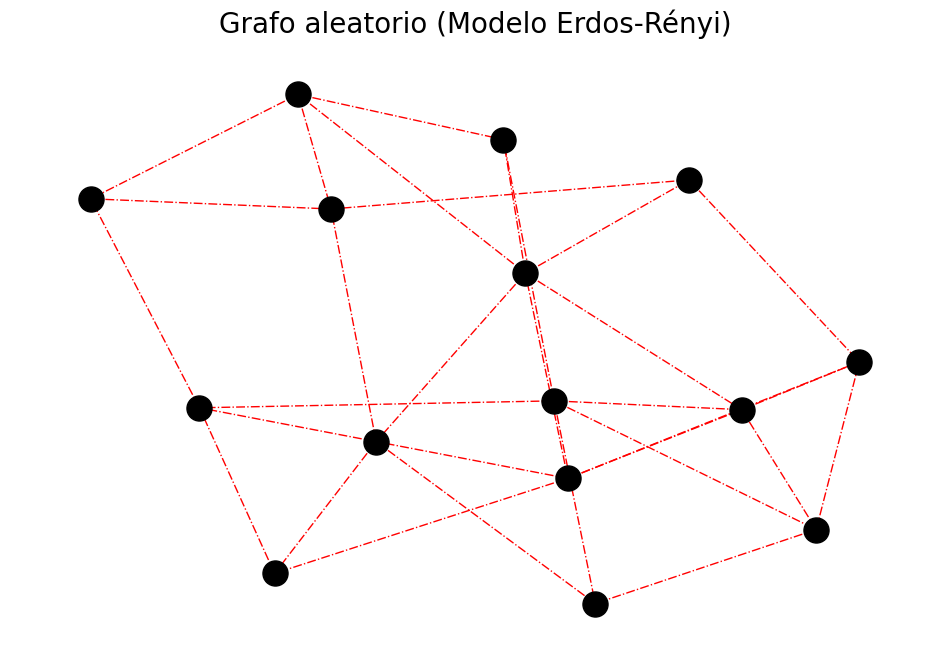

---

## Analizando el grafo con DFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Nodo inicial: 4
Nodo a buscar: 7


_iniciando búsqueda..._

### Resultados obtenidos
---

Número de pasos: 2
Camino: [4, 7]
Longitud del camino; 1 aristas


(2, [4, 7])

In [9]:
######################################
# ERDOS-RENYI
######################################

e_r = nx.erdos_renyi_graph(15, 0.25)   # 15 nodos | Probabilidad de arista del 25%

# Mostramos el grafo por pantalla
plt.figure(figsize=(12,8))
plt.title('Grafo aleatorio (Modelo Erdos-Rényi)', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(e_r, seed = 18)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(e_r, posiciones, node_color = 'black', node_size = 325)
nx.draw_networkx_edges(e_r, posiciones, edge_color = 'red', style = '-.')

plt.axis('off')
plt.show()
display(Markdown("---"))

# EJECUTAMOS EL AGORITMO
dfs_numpy(e_r, 4, 7)

---

#### **BARABASI-ALBERT**

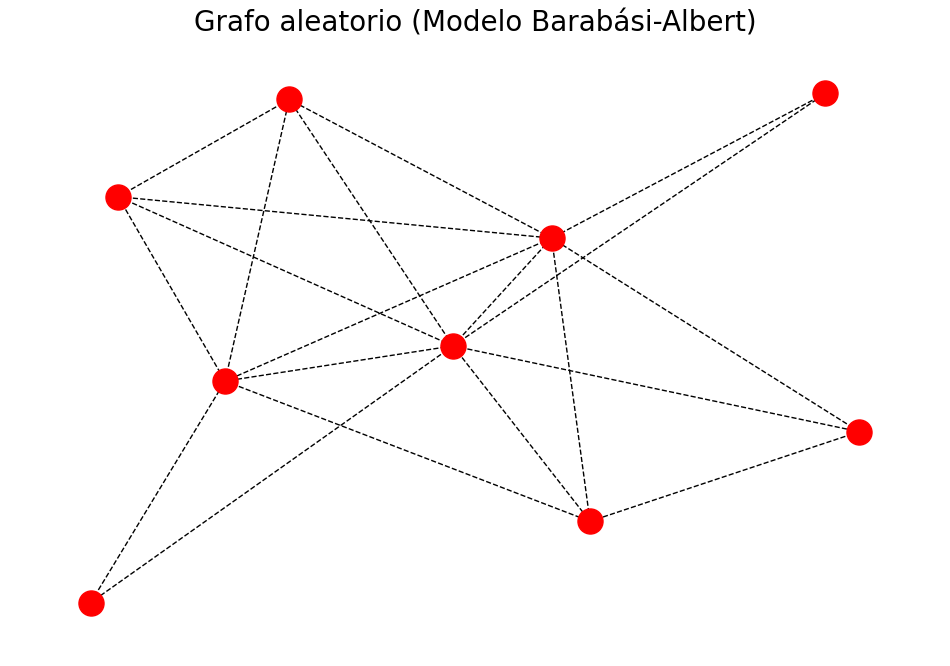

---

## Analizando el grafo con DFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Nodo inicial: 4
Nodo a buscar: 8


_iniciando búsqueda..._

### Resultados obtenidos
---

Número de pasos: 4
Camino: [4, 7, 6, 8]
Longitud del camino; 3 aristas


(4, [4, 7, 6, 8])

In [10]:
######################################
# BARABASI-ALBERT
######################################

b_a = nx.barabasi_albert_graph(9, 4, seed=10)   # 10 nodos | Nº enlaces por nodo

# Mostramos el grafo por pantalla
plt.figure(figsize=(12,8))
plt.title('Grafo aleatorio (Modelo Barabási-Albert)', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(b_a, seed = 8)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(b_a, posiciones, node_color = 'red', node_size = 325)
nx.draw_networkx_edges(b_a, posiciones, edge_color = 'black', style = '--')

plt.axis('off')
plt.show()
display(Markdown("---"))

# CALCULAMOS EL ALGORITMO
dfs_numpy(b_a, 4,8)

---

#### **WATTS-STROGATZ**

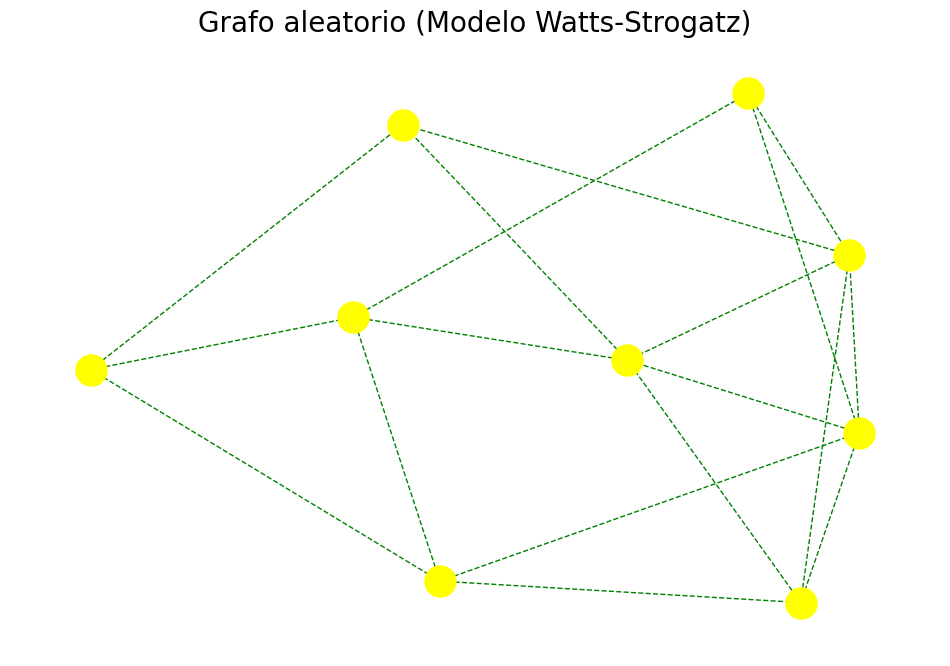

---

## Analizando el grafo con DFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Nodo inicial: 6
Nodo a buscar: 8


_iniciando búsqueda..._

### Resultados obtenidos
---

Número de pasos: 3
Camino: [6, 7, 8]
Longitud del camino; 2 aristas


(3, [6, 7, 8])

In [11]:
######################################
# WATTS-STROGATZ
######################################

w_s = nx.watts_strogatz_graph(9, 4, 0.5)   # 9 nodos | Grado medio | Probabilidad reconexión

# Mostramos el grafo por pantalla
plt.figure(figsize=(12,8))
plt.title('Grafo aleatorio (Modelo Watts-Strogatz)', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(w_s, seed = 16)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(w_s, posiciones, node_color = 'yellow', node_size = 500)
nx.draw_networkx_edges(w_s, posiciones, edge_color = 'green', style = '--')

plt.axis('off')
plt.show()
display(Markdown("---"))

# EJECUTAMOS EL ALGORTIMO
dfs_numpy(w_s, 6, 8)

#### **GRAFOS EN ÁRBOL**

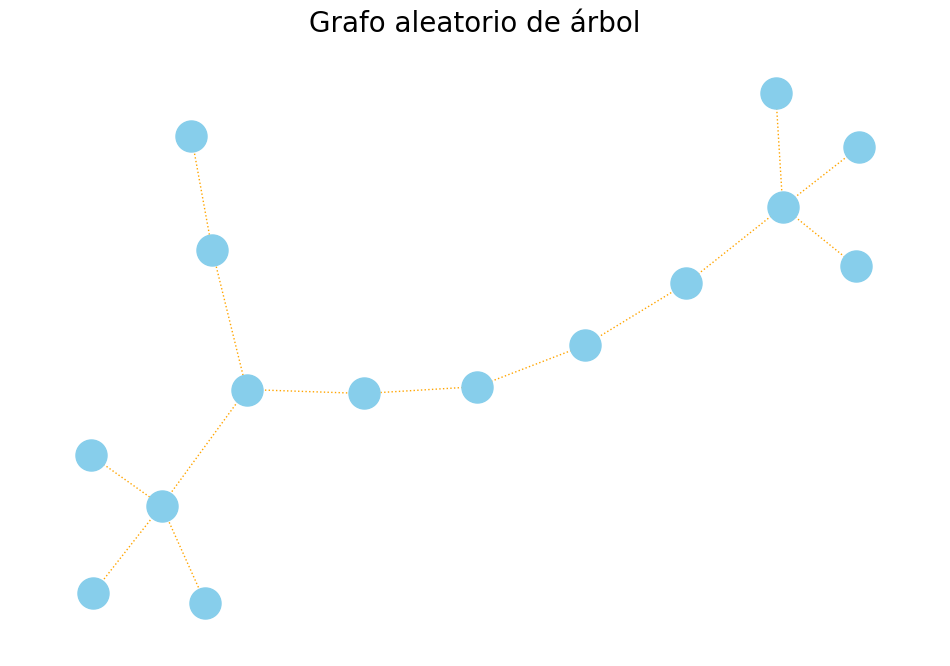

---

## Analizando el grafo con DFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Nodo inicial: 2
Nodo a buscar: 7


_iniciando búsqueda..._

### Resultados obtenidos
---

Número de pasos: 15
Camino: [2, 3, 7]
Longitud del camino; 2 aristas


(15, [2, 3, 7])

In [12]:
######################################
# TREE
######################################

# Usamos la función "random_tree" para generar un grafo de árbol
t = nx.random_tree(15, seed=99)   # 15 nodos

# Mostramos el grafo por pantalla
plt.figure(figsize=(12,8))
plt.title('Grafo aleatorio de árbol', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(t, seed = 16)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(t, posiciones, node_color = 'skyblue', node_size = 500)
nx.draw_networkx_edges(t, posiciones, edge_color = 'orange', style = ':')

plt.axis('off')
plt.show()
display(Markdown("---"))

# EJECUTAMOS EL ALGORITMO
dfs_numpy(t, 2, 7)

#### **STOCHASTIC BLOCK MODEL**

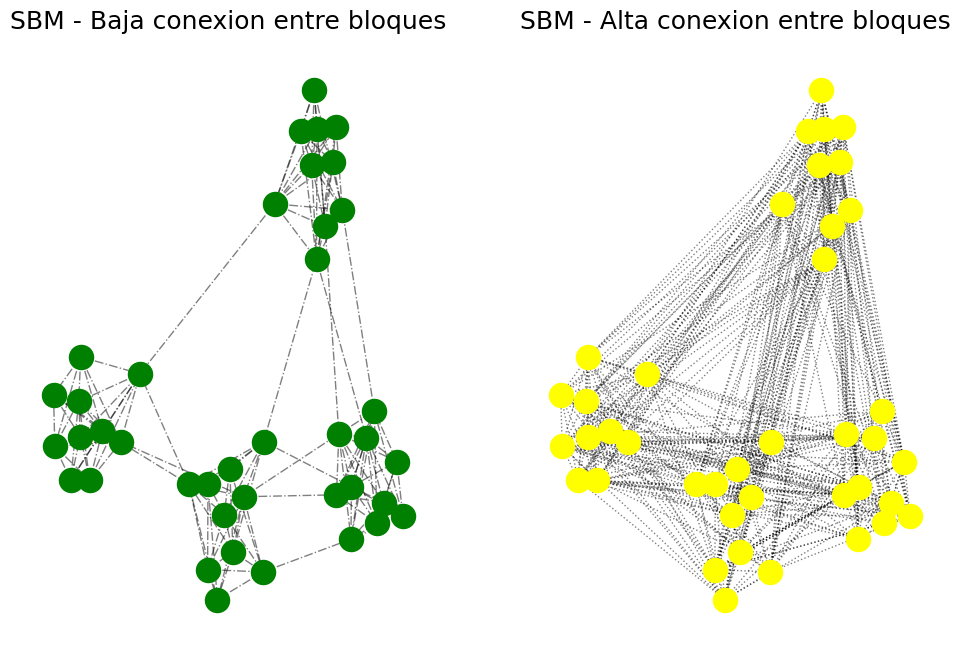

## Analizando el grafo con DFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 39, 30, 31]
Nodo inicial: 6
Nodo a buscar: 13


_iniciando búsqueda..._

### Resultados obtenidos
---

...

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 39, 30, 31]
Nodo inicial: 6
Nodo a buscar: 13


_iniciando búsqueda..._

### Resultados obtenidos
---

Número de pasos: 23
Camino: [6, 30, 13]
Longitud del camino; 2 aristas


(23, [6, 30, 13])

In [13]:
######################################
# STOCHASTIC_BLOCK_MODEL (SBM)
######################################
# Creamos 4 bloques de 10 nodos cada uno
sizes = [10, 10, 10, 10]

# Definimos las matrices de probabilidad:
    # Baja: Probabilidad baja conexión entre bloques distintos
    # Alta: Probabilidad alta conexión entre bloques distintos
baja = [
    [0.8, 0.02, 0.02, 0.02],
    [0.02, 0.8, 0.02, 0.02],
    [0.02, 0.02, 0.8, 0.02],
    [0.02, 0.02, 0.02, 0.8]
]
alta = [
    [0.8, 0.4, 0.4, 0.4],
    [0.4, 0.8, 0.4, 0.4],
    [0.4, 0.4, 0.8, 0.4],
    [0.4, 0.4, 0.4, 0.8]
]
# Definimos la semilla para que los resultados sean reproducibles
seed = 96

# Creamos los 2 grafos (SBM)
G1 = nx.stochastic_block_model(sizes, baja, seed=seed)  # El primero -> Probabilidad alta
G2 = nx.stochastic_block_model(sizes, alta, seed=seed)  # El segundo -> Probabilidad baja

# Calculamos las posiciones (las mismas para los dos grafos)
pos = nx.spring_layout(G1, seed=seed)
# Vamos a dividir los dos grafos en una misma figura
fig, axes = plt.subplots(1, 2, figsize=(12,8))

# Primer grafo
#--------------#
# Definimos título
axes[0].set_title('SBM - Baja conexion entre bloques', fontsize = 18)  
nx.draw_networkx_nodes(G1, pos, node_size=300, node_color='green', ax=axes[0])  # Dibujamos los nodos
nx.draw_networkx_edges(G1, pos, width=1.0, alpha=0.5, edge_color='black', style='-.', ax=axes[0]) # Dibujamos las aristas
axes[0].axis('off')

# Segundo grafo
#---------------#
# Definimos título
axes[1].set_title('SBM - Alta conexion entre bloques', fontsize = 18)
nx.draw_networkx_nodes(G2, pos, node_size=300, node_color= 'yellow', ax=axes[1])         # Dibujamos los nodos
nx.draw_networkx_edges(G2, pos, width=1.0, alpha=0.5, style=':', ax=axes[1])  # Dibujamos las arsitas
axes[1].axis('off')

# Mostramos el resultado por pantalla
plt.show()


# EJECUTAMOS EL ALGORITMO
dfs_numpy(G1, 6, 13)
display(Markdown(f'---'))
display(Markdown(f'---'))
dfs_numpy(G2, 6, 13)

# Ejercicio 2

Vamos a aplicar el algoritmo a los grafos sintéticos creados anteriormente mostrando un ejemplo donde los nodos destino y origen están cerca y otro donde estén lejos

---
#### **ERDOS-RÉNYI**

In [14]:
dfs_numpy(e_r, 0, 1) # CERCA
dfs_numpy(e_r, 0, 14) # LEJOS

## Analizando el grafo con DFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Nodo inicial: 0
Nodo a buscar: 1


_iniciando búsqueda..._

### Resultados obtenidos
---

...

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Nodo inicial: 0
Nodo a buscar: 14


_iniciando búsqueda..._

### Resultados obtenidos
---

Número de pasos: 8
Camino: [0, 12, 11, 13, 9, 7, 1, 14]
Longitud del camino; 7 aristas


(8, [0, 12, 11, 13, 9, 7, 1, 14])

---
#### **BARABÁSI-ALBERT**

In [15]:
dfs_numpy(b_a, 0, 1) # CERCA
dfs_numpy(b_a, 0, 5) # LEJOS

## Analizando el grafo con DFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Nodo inicial: 0
Nodo a buscar: 1


_iniciando búsqueda..._

### Resultados obtenidos
---

...

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Nodo inicial: 0
Nodo a buscar: 5


_iniciando búsqueda..._

### Resultados obtenidos
---

Número de pasos: 5
Camino: [0, 5]
Longitud del camino; 1 aristas


(5, [0, 5])

---
#### **GRAFOS DE MUNDOS PEQUEÑOS**

In [16]:
dfs_numpy(w_s, 0, 1) # CERCA
dfs_numpy(w_s, 0, 5) # LEJOS

## Analizando el grafo con DFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Nodo inicial: 0
Nodo a buscar: 1


_iniciando búsqueda..._

### Resultados obtenidos
---

...

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Nodo inicial: 0
Nodo a buscar: 5


_iniciando búsqueda..._

### Resultados obtenidos
---

Número de pasos: 7
Camino: [0, 8, 5]
Longitud del camino; 2 aristas


(7, [0, 8, 5])

---
#### **GRAFOS EN ÁRBOL**

In [17]:
dfs_numpy(t, 0, 1) # CERCA
dfs_numpy(t, 0, 14) # LEJOS

## Analizando el grafo con DFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Nodo inicial: 0
Nodo a buscar: 1


_iniciando búsqueda..._

### Resultados obtenidos
---

...

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Nodo inicial: 0
Nodo a buscar: 14


_iniciando búsqueda..._

### Resultados obtenidos
---

Número de pasos: 3
Camino: [0, 6, 14]
Longitud del camino; 2 aristas


(3, [0, 6, 14])

---
#### **MODELO DE BLOQUES ESTOCÁSTICOS**

In [18]:
# POCA CONEXIÓN ENTRE COMUNIDADES
dfs_numpy(G1, 0, 2) # CERCA
dfs_numpy(G1, 0, 35) # LEJOS

print()
print()
print()

# MUCHA CONEXIÓN ENTRE COMUNIDADES
dfs_numpy(G2, 0, 2) # CERCA
dfs_numpy(G2, 0, 35) # LEJOS

## Analizando el grafo con DFS 
---

### <u>Datos iniciales</u>

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 39, 30, 31]
Nodo inicial: 0
Nodo a buscar: 2


_iniciando búsqueda..._

### Resultados obtenidos
---

...

Nodos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 39, 30, 31]
Nodo inicial: 0
Nodo a buscar: 35


_iniciando búsqueda..._

### Resultados obtenidos
---

Número de pasos: 6
Camino: [0, 31, 30, 35]
Longitud del camino; 3 aristas


(6, [0, 31, 30, 35])

# Resultados obtenidos y conclusión

Hemos aplicado el algoritmo DFS a los cinco tipos de grafos sintéticos. En el grafo de Erdős-Rényi, al ser aleatorio, DFS puede encontrar caminos de longitud variable dependiendo de la rama que explore primero, no necesariamente la más corta. En Barabási-Albert, aunque los hubs siguen facilitando la conectividad, DFS puede ignorarlos si la rama que elige primero va en otra dirección, lo que puede resultar en caminos más largos que los que encontraría BFS. En Watts-Strogatz, la propiedad de mundo pequeño sigue presente, pero DFS puede desaprovecharla al profundizar por una rama larga antes de explorar conexiones más directas. El árbol es el único caso donde DFS y BFS encuentran exactamente el mismo camino, ya que al no haber ciclos ni atajos existe un único camino posible entre cualquier par de nodos. En el SBM, DFS puede tener un comportamiento muy irregular: en G1 puede tardar mucho en encontrar el puente entre comunidades si se adentra profundamente en la comunidad equivocada, mientras que en G2 la alta densidad de conexiones hace que ambos algoritmos se comporten de forma más similar.

**¿Cómo se comporta el algoritmo en estos grafos?** \
&rarr;  DFS funciona correctamente en todos los grafos en el sentido de que siempre encuentra un camino si existe. Sin embargo, al explorar en profundidad en lugar de por niveles, no garantiza que ese camino sea el más corto. El comportamiento depende mucho de la estructura del grafo: en grafos muy densos la diferencia con BFS es pequeña, pero en grafos dispersos o con estructura de comunidades DFS puede encontrar caminos notablemente más largos.

**¿Cómo se compara la ruta DFS con la ruta más corta que encuentra BFS?** \
&rarr; BFS siempre garantiza el camino más corto porque explora por niveles: primero todos los nodos a distancia 1, luego a distancia 2, y así sucesivamente. DFS en cambio se adentra por una rama hasta el fondo antes de retroceder, por lo que el camino que encuentra depende del orden en que se exploran los vecinos. En grafos con muchos caminos alternativos, DFS puede encontrar un camino válido pero con más saltos de los necesarios. El árbol es la excepción: al haber un único camino posible, ambos algoritmos obtienen el mismo resultado.

**¿En qué casos podría ser más apropiado DFS que BFS?** \
&rarr; DFS es más apropiado cuando no nos importa encontrar el camino más corto sino simplemente saber si existe un camino entre dos nodos. También es preferible cuando el grafo es muy profundo y el destino está lejos del origen, ya que BFS tendría que explorar muchísimos nodos por niveles antes de llegar. Otro caso típico es la detección de ciclos o el recorrido completo del grafo, donde la exploración en profundidad es más natural. En cambio, para encontrar el camino más corto en grafos no ponderados, BFS siempre es la mejor opción.